## AuxTel Mount fails - 08-Mar-21

In this notebook, investigate observed mount fails during the observing night 18-Feb-21

In [1]:
import sys, time, os, asyncio

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time, TimeDelta
from astropy.coordinates import AltAz, ICRS, EarthLocation, Angle, FK5
import astropy.units as u
from lsst_efd_client import EfdClient
from lsst.geom import PointD
import lsst.daf.persistence as dafPersist

#from lsst.daf.persistence.dafPersist import Butler

In [ ]:
# Set Cerro Pachon location
location = EarthLocation.from_geodetic(lon=-70.747698*u.deg,
                                       lat=-30.244728*u.deg,
                                       height=2663.0*u.m)

In [2]:
# Get EFD client and bring in Lupton's unpacking code
client = EfdClient('summit_efd')

def merge_packed_time_series(packed_dataframe, base_field, stride=1, 
                             ref_timestamp_col="cRIO_timestamp", internal_time_scale="tai"):
    """Select fields that are time samples and unpack them into a dataframe.
            Parameters
            ----------
            packedDF : `pandas.DataFrame`
                packed data frame containing the desired data
            base_field :  `str`
                Base field name that will be expanded to query all
                vector entries.
            stride : `int`, optional
                Only use every stride value when unpacking.  Must be a factor
                of the number of packed values.
                (1 by default)
            ref_timestamp_col : `str`, optional
                Name of the field name to use to assign timestamps to unpacked
                vector fields (default is 'cRIO_timestamp').
            internal_time_scale : `str`, optional
                Time scale to use when converting times to internal formats
                ('tai' by default). Equivalent to EfdClient.internal_scale
        Returns
            -------
            result : `pandas.DataFrame`
                A `pandas.DataFrame` containing the results of the query.
            """
    
    packed_fields = [k for k in packed_dataframe.keys() if k.startswith(base_field)]
    packed_fields = sorted(packed_fields, key=lambda k: int(k[len(base_field):]))  # sort by pack ID
    npack = len(packed_fields)
    if npack%stride != 0:
        raise RuntimeError(f"Stride must be a factor of the number of packed fields: {stride} v. {npack}")
    packed_len = len(packed_dataframe)
    n_used = npack//stride   # number of raw fields being used
    output = np.empty(n_used*packed_len)
    times = np.empty_like(output, dtype=packed_dataframe[ref_timestamp_col][0])
    
    if packed_len == 1:
        dt = 0
    else:
        dt = (packed_dataframe[ref_timestamp_col][1] - packed_dataframe[ref_timestamp_col][0])/npack
    for i in range(0, npack, stride):
        i0 = i//stride
        output[i0::n_used] = packed_dataframe[f"{base_field}{i}"]
        times[i0::n_used] = packed_dataframe[ref_timestamp_col] + i*dt
     
    timestamps = Time(times, format='unix', scale=internal_time_scale).datetime64
    return pd.DataFrame({base_field:output, "times":times}, index=timestamps)

In [11]:
# Get the data
t_end = Time('2021-03-09T16:29:00', scale='tai')
t_start = Time('2021-03-09T16:28:30', scale='tai')
nasmyth_position = await client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders", ['*'],
                                          t_start, t_end)
torques = await client.select_time_series("lsst.sal.ATMCS.measuredTorque", ['*'],
                                          t_start, t_end)

rot = merge_packed_time_series(nasmyth_position, 'nasmyth2CalculatedAngle', stride=1) 
rot_torque =  merge_packed_time_series(torques, 'nasmyth2MotorTorque', stride=1)


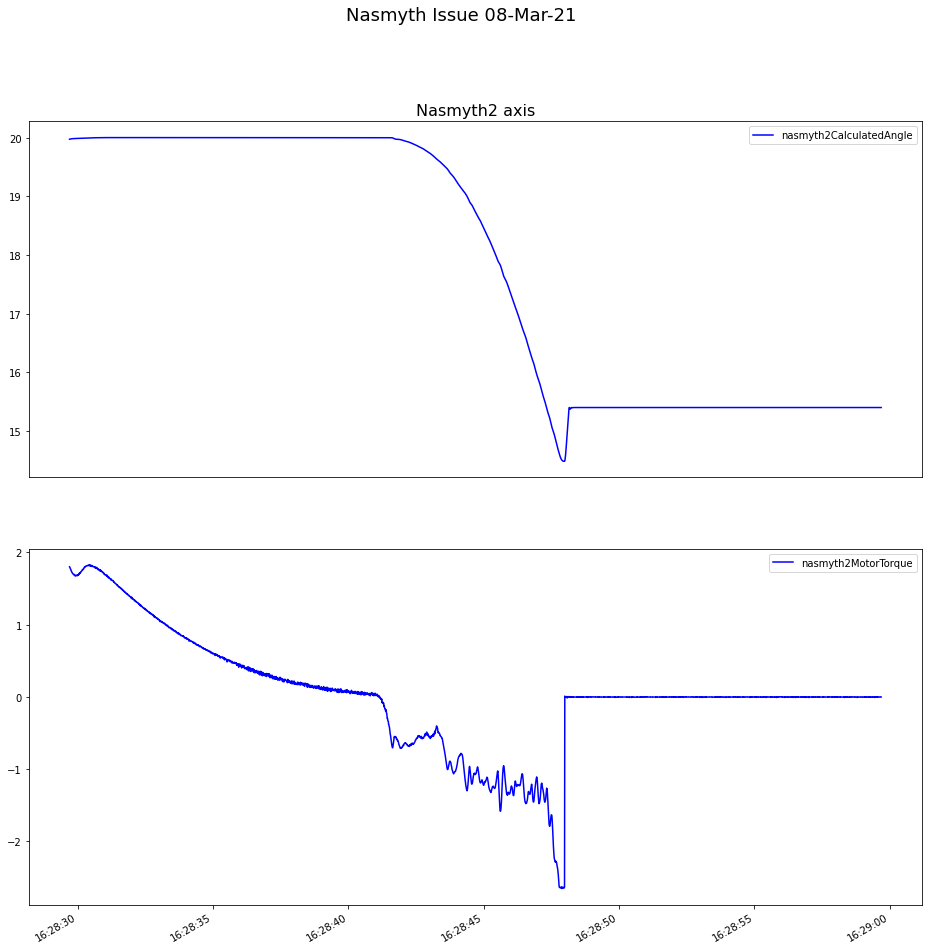

In [12]:
# Plot it
fig = plt.figure(figsize = (16,16))
plt.suptitle("Nasmyth Issue 08-Mar-21", fontsize = 18)

# Nasmyth2 rotator axis
plt.subplot(2,1,1)
ax3 = rot['nasmyth2CalculatedAngle'].plot(legend=True, color='blue')
ax3.set_title("Nasmyth2 axis", fontsize=16)
ax3.set_xticks([])
plt.subplot(2,1,2)
ax9 = rot_torque['nasmyth2MotorTorque'].plot(legend=True, color='blue')

#plt.savefig(f"/home/craiglagegit/DATA/mount_graphs/Nasmyth_Fails_08Mar21_160-0_WithHelp.pdf")